<a href="https://colab.research.google.com/github/Kondam-Rahul-Reddy/Projects/blob/main/Project_2_Bike_Sharing_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Evaluation Metrics
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import joblib

In [ ]:
df = pd.read_csv("bike.csv")

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [ ]:
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796
729,730,31-12-2019,1,1,12,0,1,1,2,8.849153,11.17435,57.7500,10.374682,439,2290,2729


In [ ]:
df.shape

(730, 16)

In [ ]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    str    
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.4 KB


In [ ]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [ ]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate Rows : 0


In [ ]:
df.shape

(730, 16)

In [ ]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)
print(df.dtypes)

instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


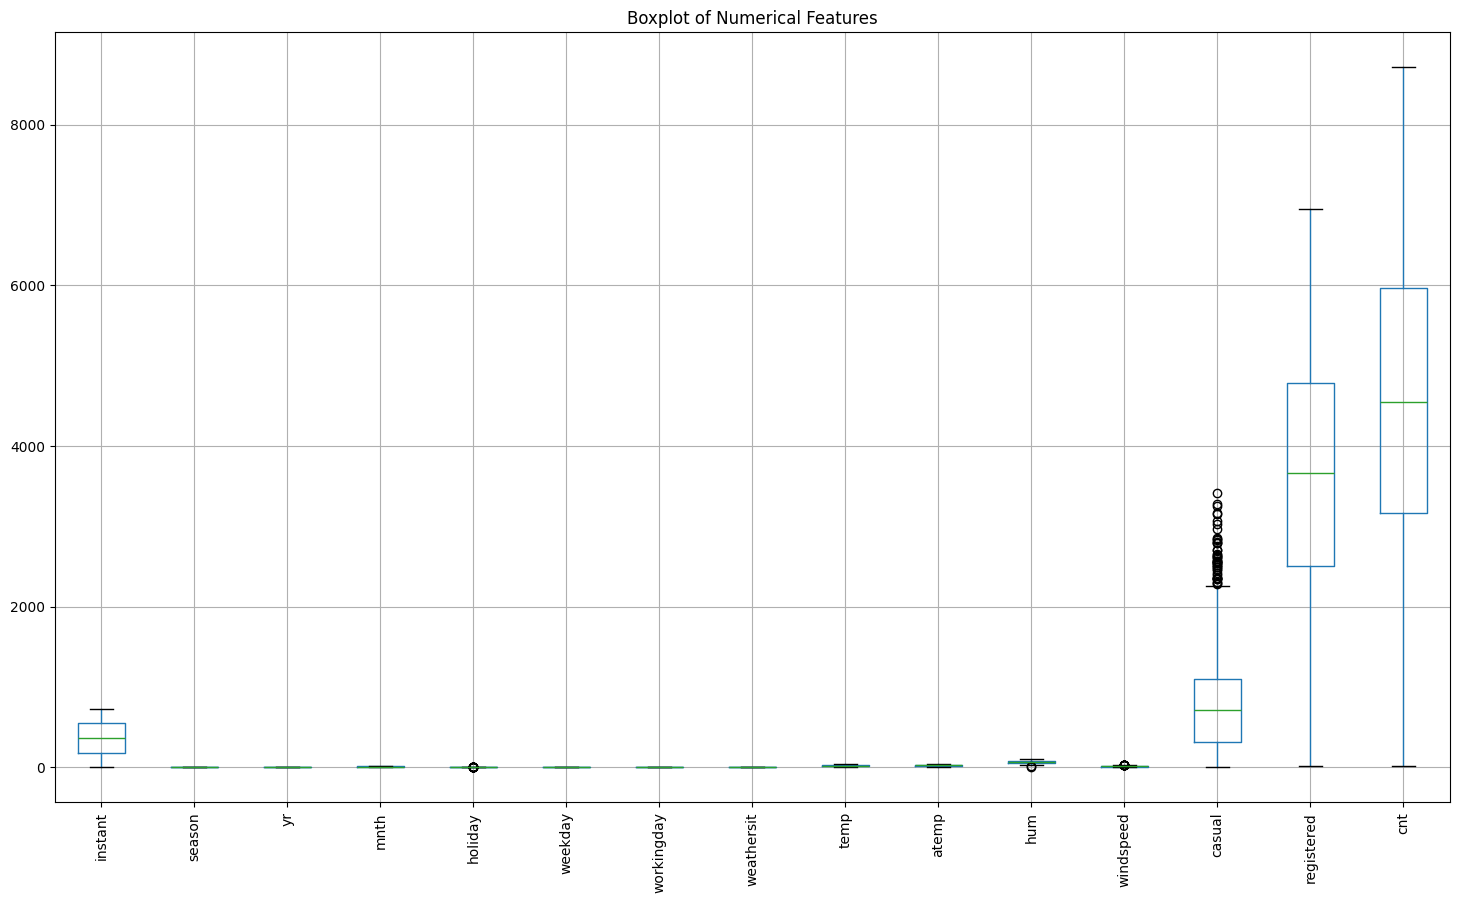

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(18,10))
df[numerical_columns].boxplot(rot=90)
plt.title("Boxplot of Numerical Features")
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
mask = ~((numeric_df < (Q1 - 1.5 * IQR)) |
         (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask]

print("Dataset Shape After Removing Outliers :", df.shape)

Dataset Shape After Removing Outliers : (654, 16)


In [ ]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,2018-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,2018-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,2018-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,2018-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


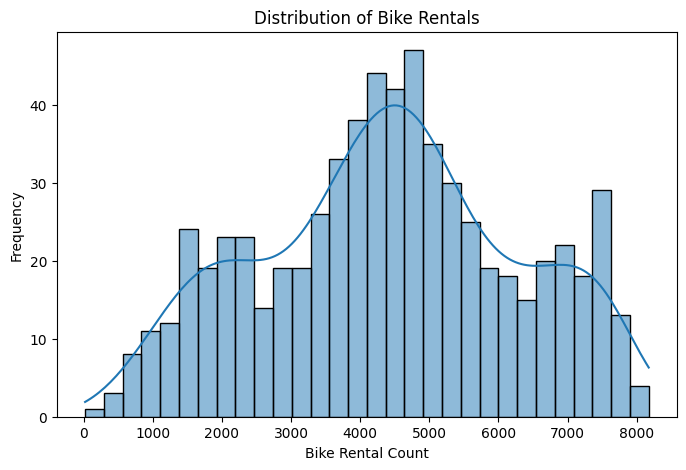

In [ ]:
# =========================================================
# Target Variable Distribution
# =========================================================

plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribution of Bike Rentals")
plt.xlabel("Bike Rental Count")
plt.ylabel("Frequency")
plt.show()

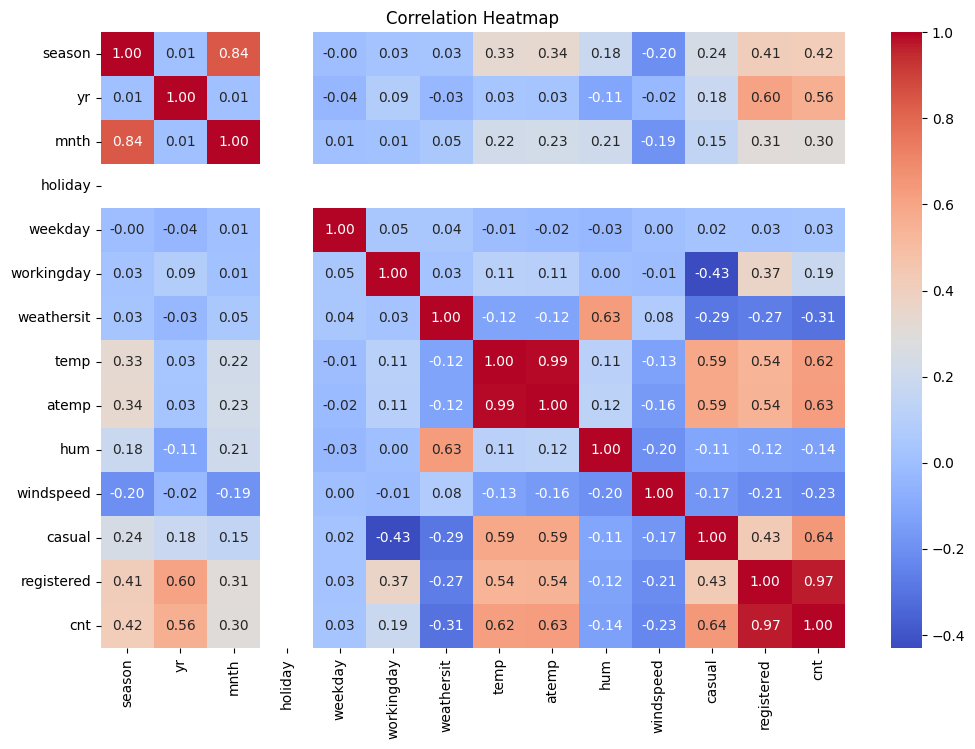

In [ ]:
# =========================================================
# Correlation Heatmap
# =========================================================

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

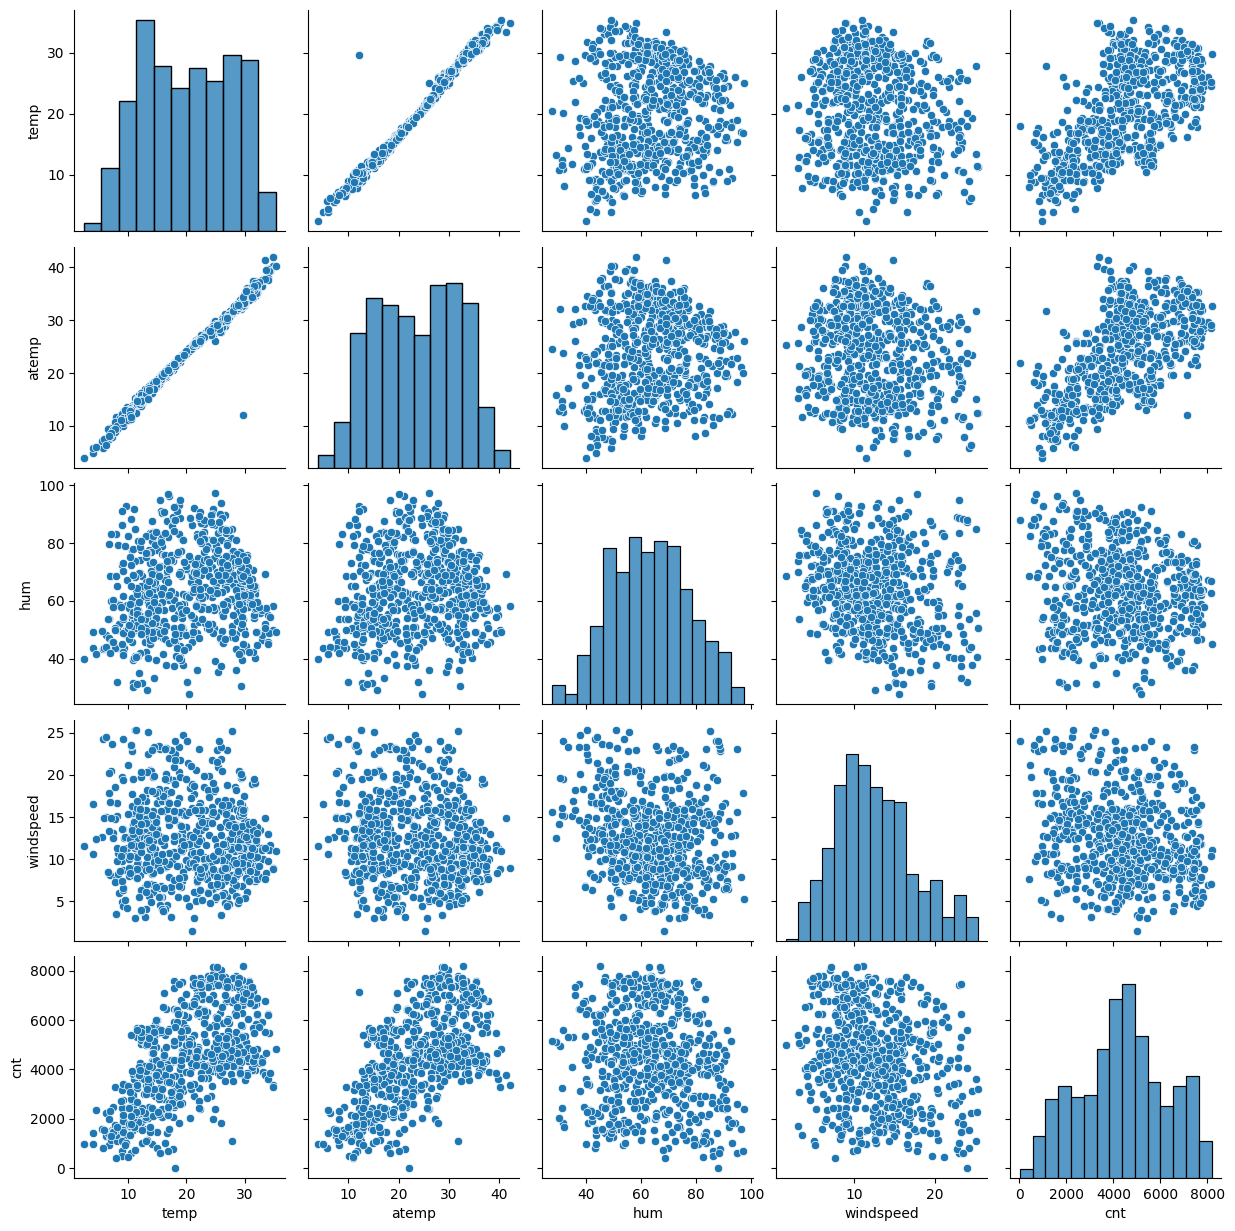

In [ ]:
# =========================================================
# Pair Plot
# =========================================================

sns.pairplot(df[['temp','atemp','hum','windspeed','cnt']])
plt.show()

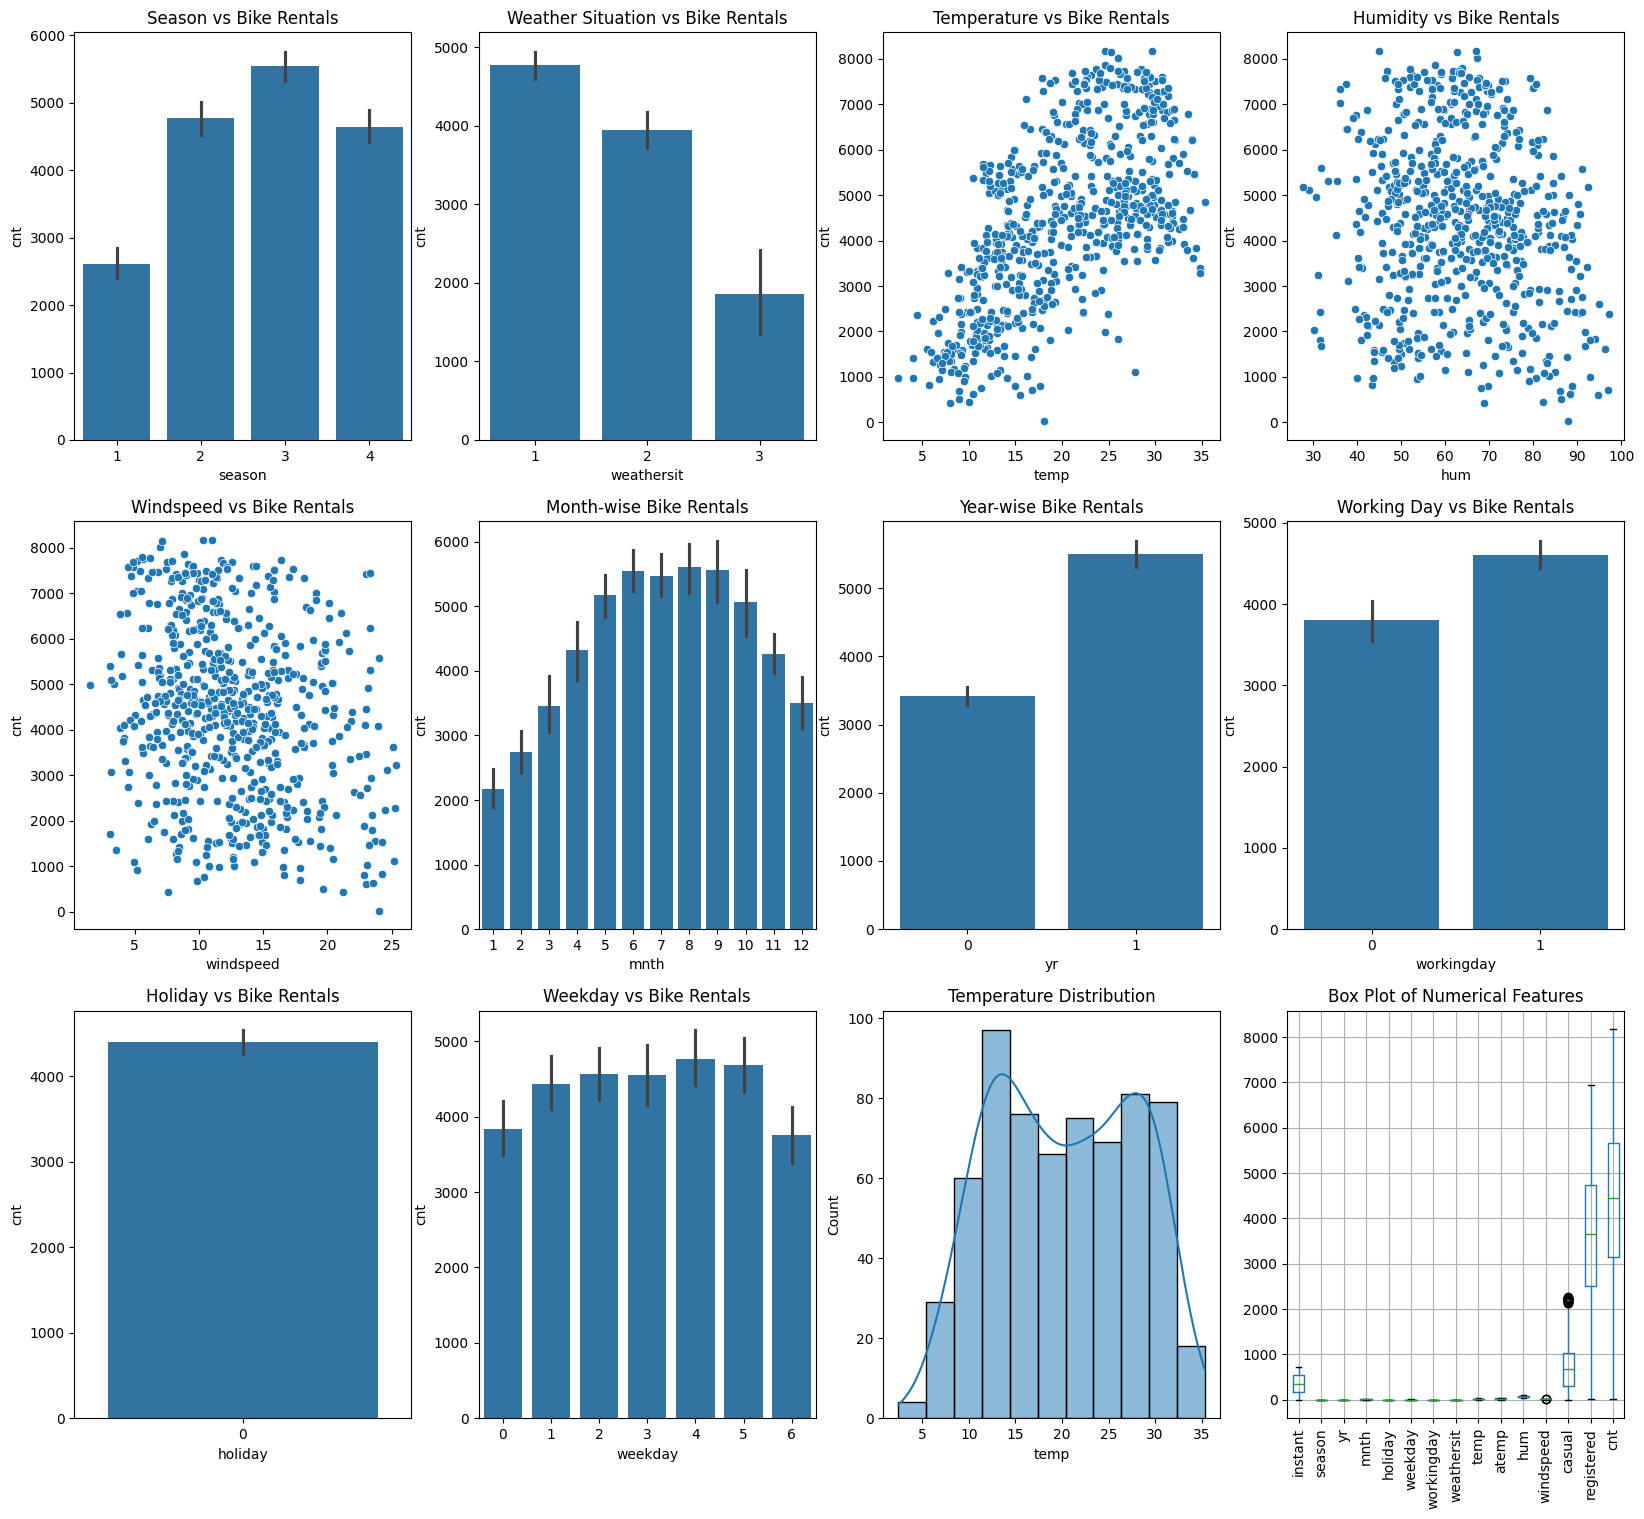

In [ ]:
plt.figure(figsize=(20,18))
plt.subplot(3,4,1)
sns.barplot(x='season', y='cnt', data=df)
plt.title("Season vs Bike Rentals")

plt.subplot(3,4,2)
sns.barplot(x='weathersit', y='cnt', data=df)
plt.title("Weather Situation vs Bike Rentals")

plt.subplot(3,4,3)
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Bike Rentals")

plt.subplot(3,4,4)
sns.scatterplot(x='hum', y='cnt', data=df)
plt.title("Humidity vs Bike Rentals")

plt.subplot(3,4,5)
sns.scatterplot(x='windspeed', y='cnt', data=df)
plt.title("Windspeed vs Bike Rentals")

plt.subplot(3,4,6)
sns.barplot(x='mnth', y='cnt', data=df)
plt.title("Month-wise Bike Rentals")

plt.subplot(3,4,7)
sns.barplot(x='yr', y='cnt', data=df)
plt.title("Year-wise Bike Rentals")

plt.subplot(3,4,8)
sns.barplot(x='workingday', y='cnt', data=df)
plt.title("Working Day vs Bike Rentals")

plt.subplot(3,4,9)
sns.barplot(x='holiday', y='cnt', data=df)
plt.title("Holiday vs Bike Rentals")

plt.subplot(3,4,10)
sns.barplot(x='weekday', y='cnt', data=df)
plt.title("Weekday vs Bike Rentals")

plt.subplot(3,4,11)
sns.histplot(df['temp'], kde=True)
plt.title("Temperature Distribution")

plt.subplot(3,4,12)
df.select_dtypes(include='number').boxplot(rot=90)
plt.title("Box Plot of Numerical Features")

plt.show()

In [ ]:
columns_to_drop = ['instant', 'dteday']
df.drop(columns=columns_to_drop, inplace=True)
print(df.columns)
df.head()

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='str')


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [ ]:
# =========================================================
# Feature Selection
# =========================================================

X = df.drop('cnt', axis=1)
y = df['cnt']
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

X.head()

Feature Shape : (654, 13)
Target Shape : (654,)


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518


In [ ]:
y.head()

0     985
1     801
2    1349
3    1562
4    1600
Name: cnt, dtype: int64

In [ ]:
X.dtypes

season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
dtype: object

In [ ]:
# =========================================================
# Label Encoding
# =========================================================
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])
print("Encoding Completed")

Encoding Completed


In [ ]:
# =========================================================
# Train Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (523, 13)
Testing Features : (131, 13)
Training Target : (523,)
Testing Target : (131,)


In [ ]:
# =========================================================
# Standardization
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled[:5]

array([[ 1.36203633, -0.98293714,  1.60155383,  0.        ,  0.51958971,
         0.59280789, -0.73463843, -1.24646275, -1.33418087, -0.38581534,
         0.75479464, -1.14278225, -0.33259068],
       [-0.45054637,  1.01735906, -0.43998119,  0.        , -1.53519607,
        -1.68688714, -0.73463843,  0.62004558,  0.65742626, -0.4127266 ,
         0.5498938 ,  2.67228573,  0.15541119],
       [-1.35683772, -0.98293714,  1.60155383,  0.        ,  0.00589327,
         0.59280789, -0.73463843, -1.06718659, -1.19443472, -0.93184134,
         1.49402026, -0.94467041, -1.04189573],
       [-1.35683772, -0.98293714, -1.60657263,  0.        , -1.02149962,
         0.59280789,  1.1125534 , -1.70411579, -1.76300428, -0.21537732,
         0.02979044, -1.34655443, -1.41262583],
       [ 1.36203633,  1.01735906,  0.72661025,  0.        ,  1.03328616,
         0.59280789,  1.1125534 ,  0.65594174,  0.66121777,  0.40358181,
        -0.28580979,  0.54588533,  1.68372713]])

In [ ]:
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 523
Testing Samples : 131


#### 1. Linear Regression

In [ ]:
# =========================================================
# Build Linear Regression Model and Prediction
# =========================================================

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_lr = linear_model.predict(X_test_scaled)
print(y_pred_lr[:10])

[3750. 2210. 7446. 3926. 3163. 3095. 1851. 2192. 5180. 1446.]


In [ ]:
# =========================================================
# Evaluation Metrics
# =========================================================

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-"*40)
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE :", rmse_lr)
print("R2 Score :", r2_lr)

Linear Regression Performance
----------------------------------------
MAE : 1.2496873764818862e-12
MSE : 2.301582696760142e-24
RMSE : 1.5170967987442799e-12
R2 Score : 1.0


In [ ]:
comparison_lr = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})
comparison_lr.head(10)

,Actual,Predicted
353,3750,3750.0
83,2210,2210.0
557,7446,7446.0
308,3926,3926.0
384,3163,3163.0
726,3095,3095.0
59,1851,1851.0
74,2192,2192.0
165,5180,5180.0
58,1446,1446.0


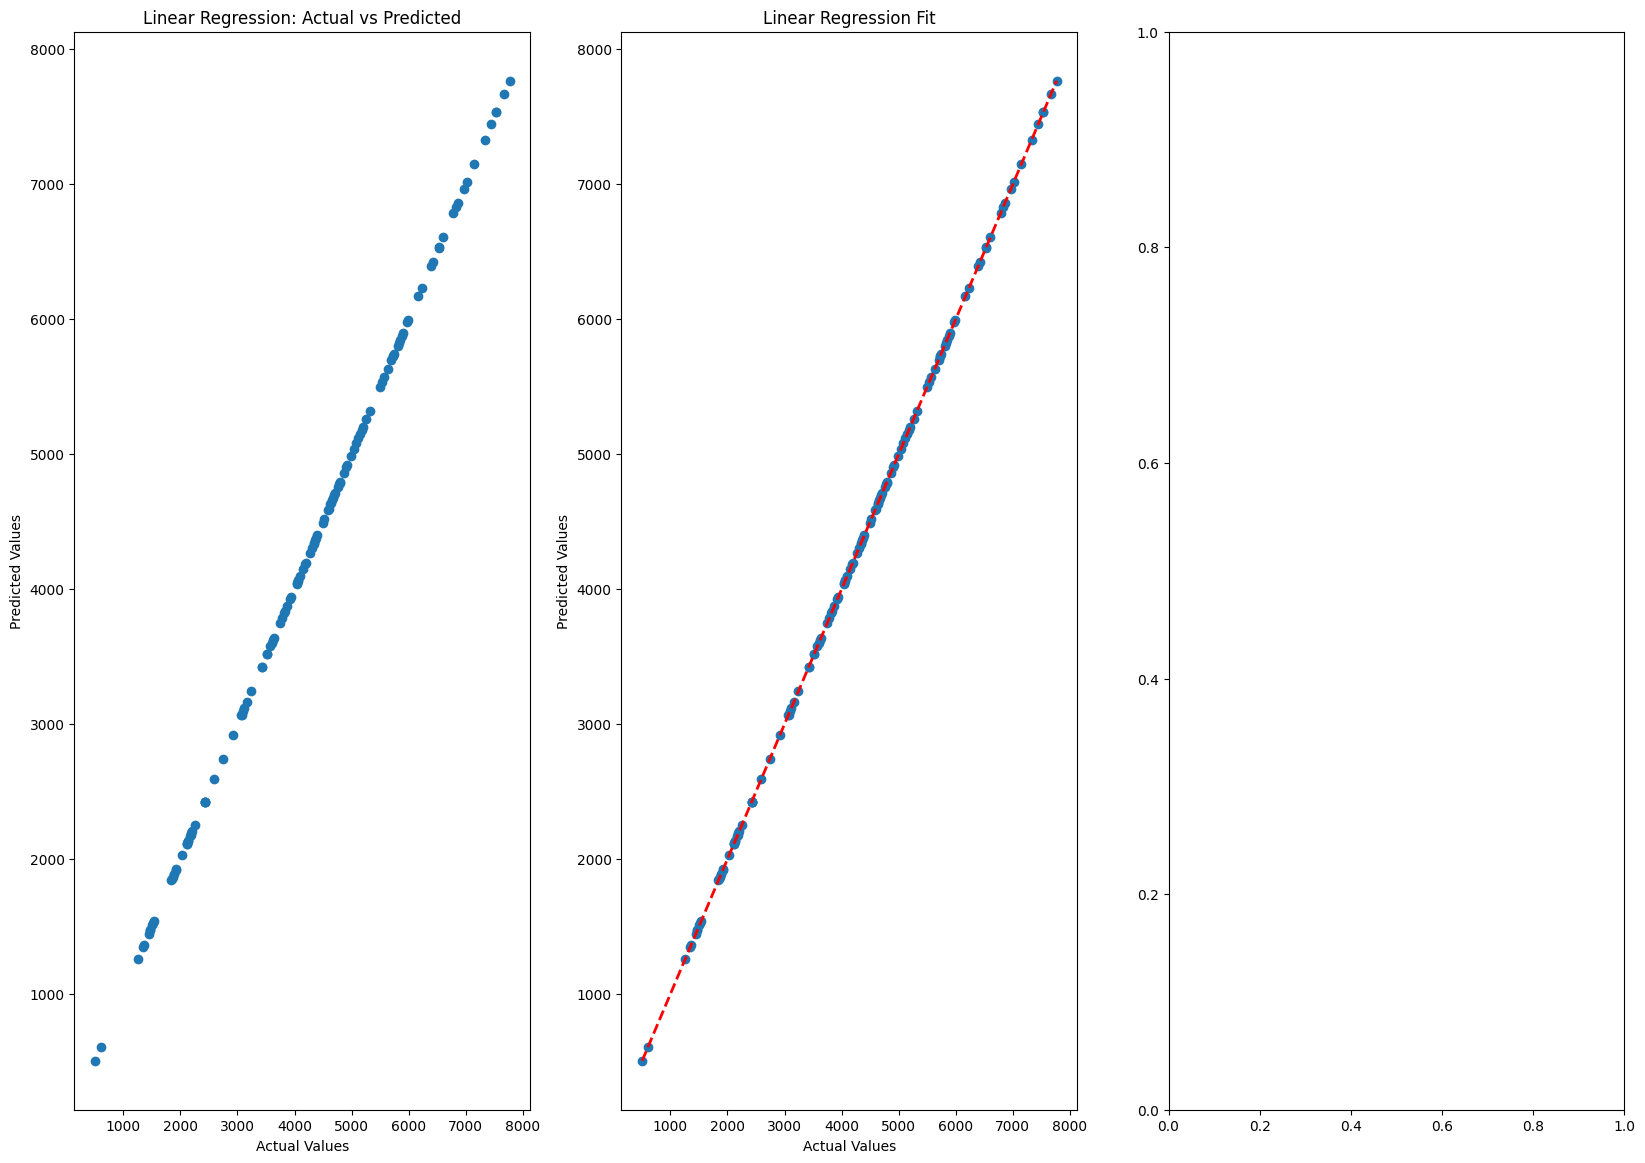

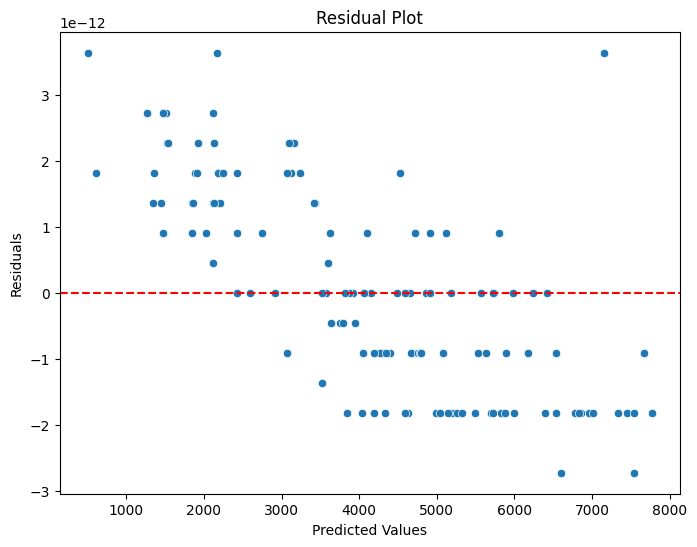

In [ ]:
# =========================================================
# Scatter Plot
# =========================================================

plt.figure(figsize=(20,14))
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

# =========================================================
# Q7.6 : Regression Line
# =========================================================
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression Fit")

plt.subplot(1,3,3)
residuals = y_test - y_pred_lr
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_pred_lr, y = residuals)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
results = []
results.append({
    "Model":"Linear Regression",
    "MAE":mae_lr,
    "MSE":mse_lr,
    "RMSE":rmse_lr,
    "R2 Score":r2_lr
})
print(results)

[{'Model': 'Linear Regression', 'MAE': 1.2496873764818862e-12, 'MSE': 2.301582696760142e-24, 'RMSE': np.float64(1.5170967987442799e-12), 'R2 Score': 1.0}]


#### 2. Decision Trees

In [ ]:
# =========================================================
# Build Decision Tree Regressor and Prediction
# =========================================================
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X_train_scaled, y_train)

y_pred_dt = decision_tree.predict(X_test_scaled)
print(y_pred_dt[:10])

[3740. 2475. 7424. 4220. 3214. 3409. 1944. 2056. 5312. 1461.]


In [ ]:
# =========================================================
# Evaluation Metrics
# =========================================================
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-"*40)
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE :", rmse_dt)
print("R2 Score :", r2_dt)

Decision Tree Performance
----------------------------------------
MAE : 125.57251908396947
MSE : 28604.702290076337
RMSE : 169.1292472935309
R2 Score : 0.9906433312466744


In [ ]:
comparison_dt = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})
comparison_dt.head(10)

,Actual,Predicted
353,3750,3740.0
83,2210,2475.0
557,7446,7424.0
308,3926,4220.0
384,3163,3214.0
726,3095,3409.0
59,1851,1944.0
74,2192,2056.0
165,5180,5312.0
58,1446,1461.0


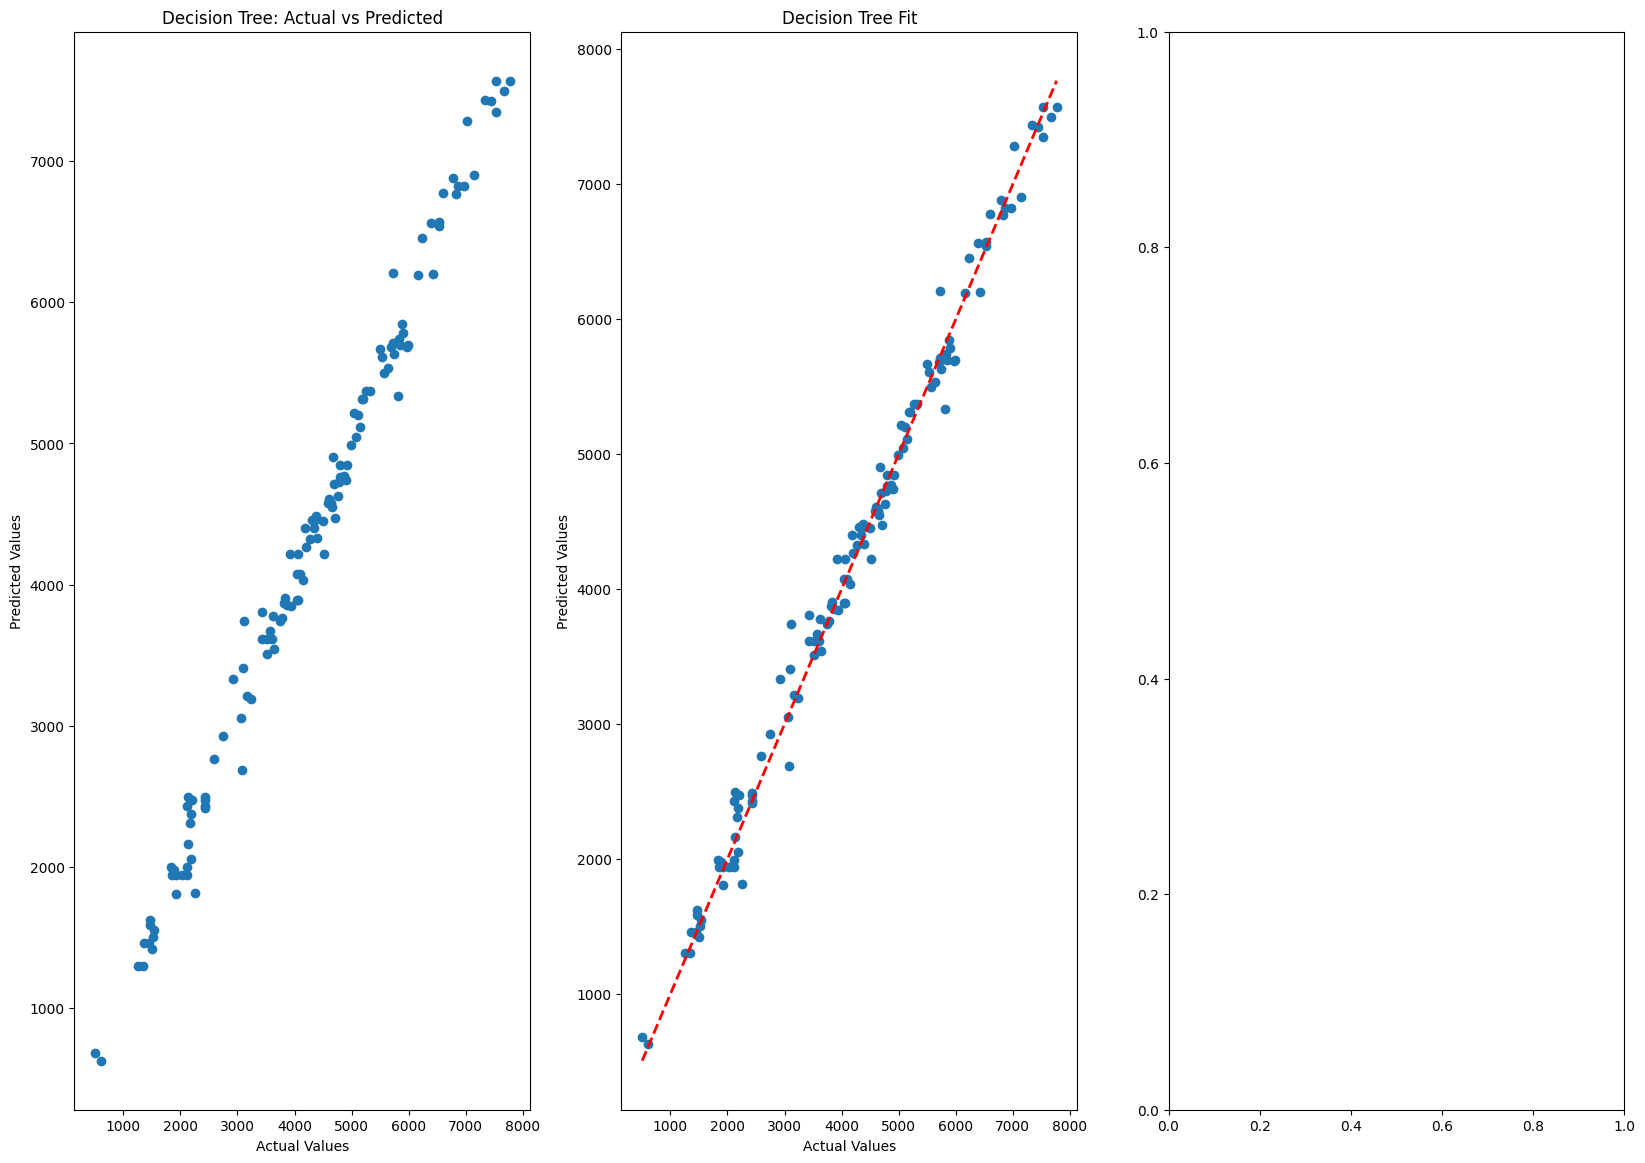

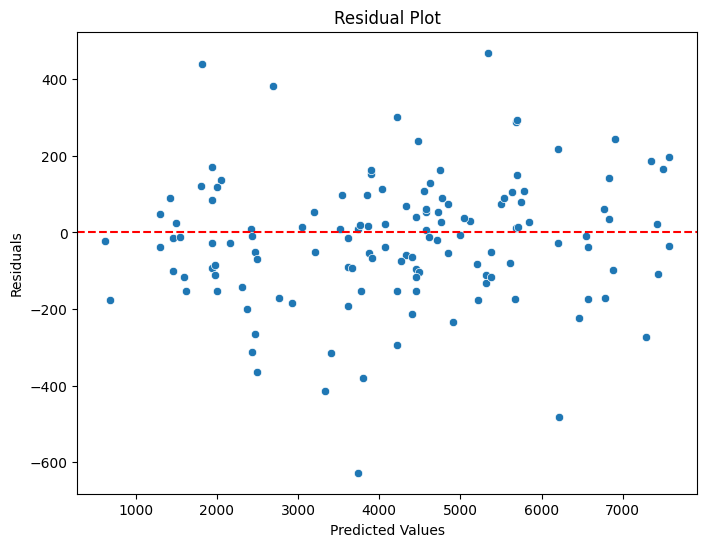

In [ ]:
# =========================================================
# Scatter Plot
# =========================================================

plt.figure(figsize=(20,14))
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")

# =========================================================
# Q7.6 : Regression Line
# =========================================================
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_dt)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree Fit")

plt.subplot(1,3,3)
residuals = y_test - y_pred_dt
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_pred_dt, y = residuals)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
results.append({
    "Model":"Decision Tree",
    "MAE":mae_dt,
    "MSE":mse_dt,
    "RMSE":rmse_dt,
    "R2 Score":r2_dt
})
pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.249687e-12,2.301583e-24,1.517097e-12,1.000000
1,Decision Tree,1.255725e+02,2.860470e+04,1.691292e+02,0.990643


#### 3. Random Forest

In [ ]:
# =========================================================
# Build Random Forest Regressor and Prediction
# =========================================================

random_forest = RandomForestRegressor(n_estimators=100, random_state = 42)
random_forest.fit(X_train_scaled, y_train)

y_pred_rf = random_forest.predict(X_test_scaled)
print(y_pred_rf[:10])

[3733.74 2267.57 7476.81 3955.36 3170.5  3133.33 1880.61 2205.44 5198.8
 1497.35]


In [ ]:
# =========================================================
# Evaluation Metrics
# =========================================================

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-"*40)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

Random Forest Performance
----------------------------------------
MAE : 64.7293893129771
MSE : 8378.66295801527
RMSE : 91.53503677835755
R2 Score : 0.9972593186568103


In [ ]:
comparison_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})
comparison_rf.head(10)

,Actual,Predicted
353,3750,3733.74
83,2210,2267.57
557,7446,7476.81
308,3926,3955.36
384,3163,3170.50
726,3095,3133.33
59,1851,1880.61
74,2192,2205.44
165,5180,5198.80
58,1446,1497.35


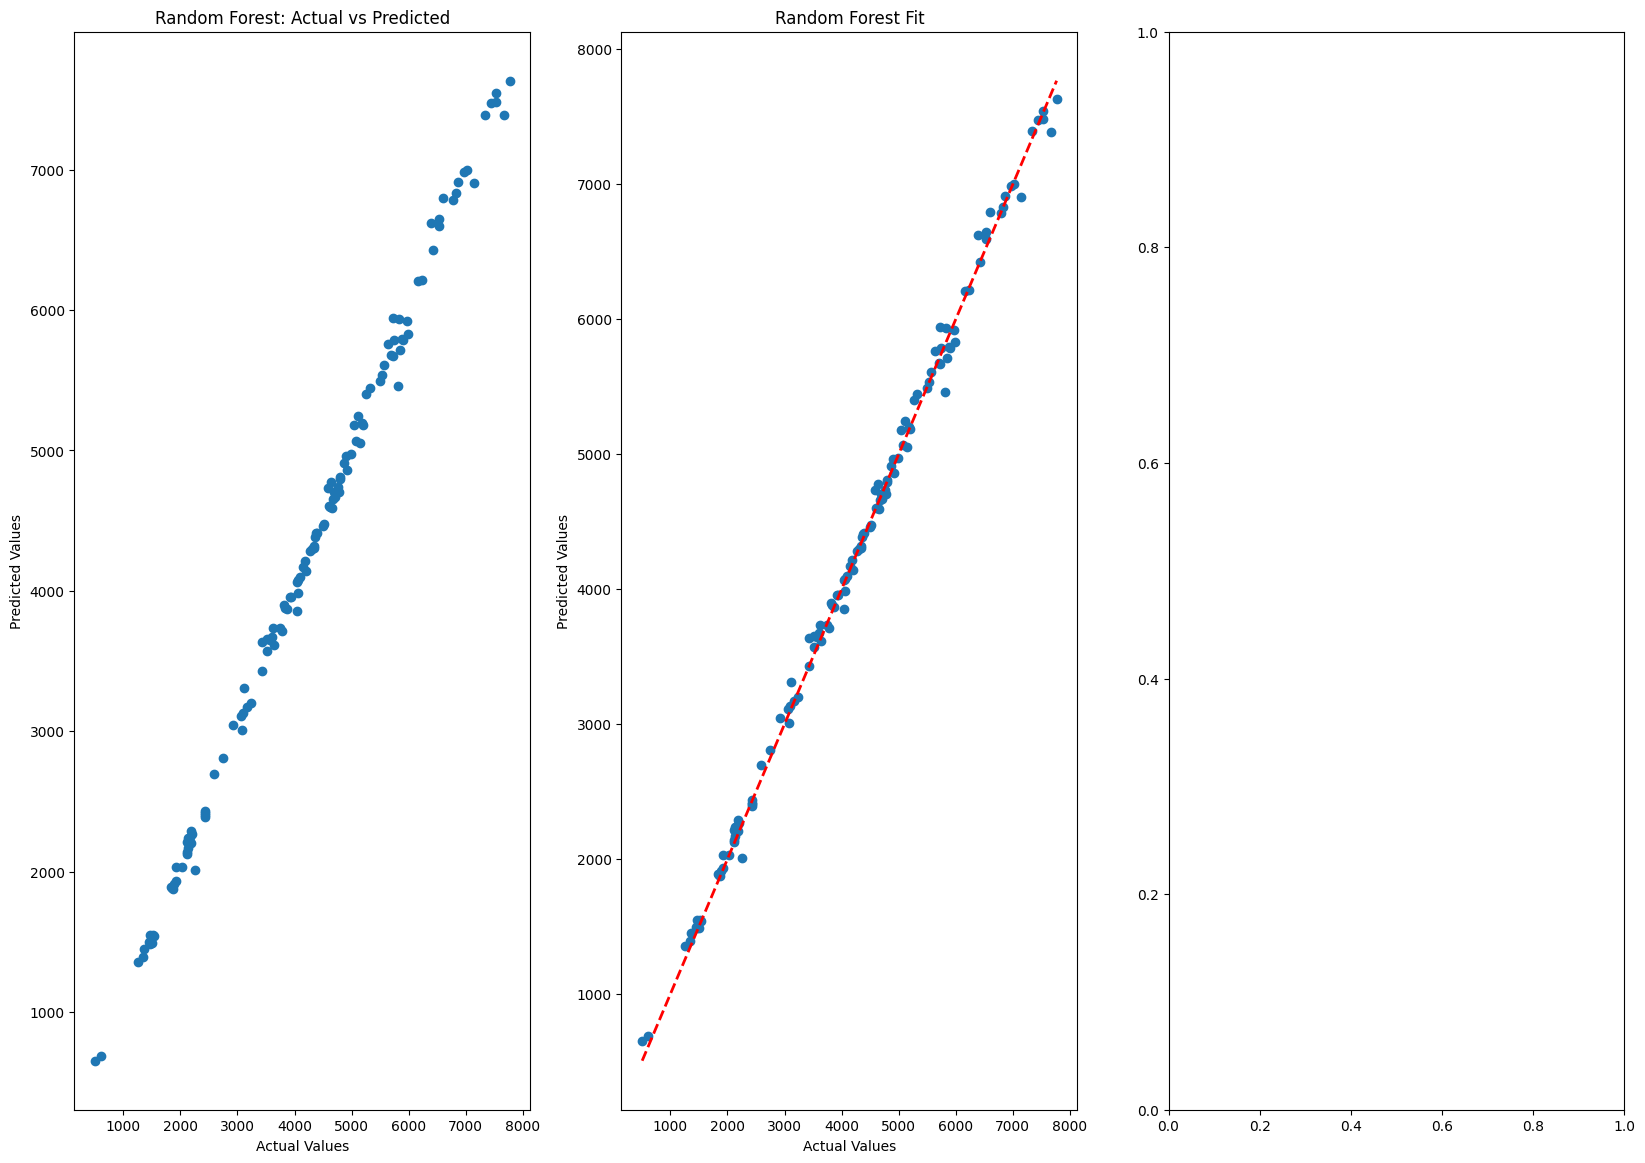

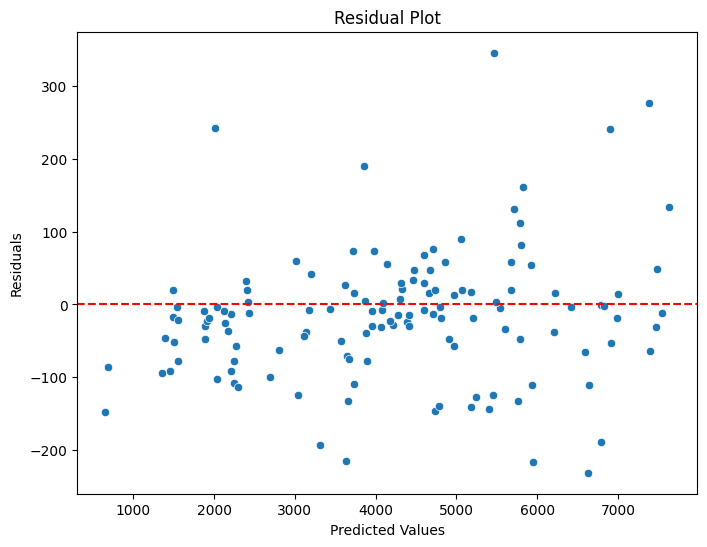

In [ ]:
# =========================================================
# QScatter Plot
# =========================================================

plt.figure(figsize=(20,14))
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

# =========================================================
# Q9.6 : Regression Line
# =========================================================
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Fit")

plt.subplot(1,3,3)
residuals = y_test - y_pred_rf
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_pred_rf, y = residuals)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
# =========================================================
# Feature Importance
# =========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})
importance = importance.sort_values(by = "Importance", ascending = False)
importance

,Feature,Importance
12,registered,0.941041
11,casual,0.054949
7,temp,0.000725
8,atemp,0.000695
10,windspeed,0.000578
9,hum,0.000557
2,mnth,0.000501
4,weekday,0.000286
0,season,0.000254
1,yr,0.000239


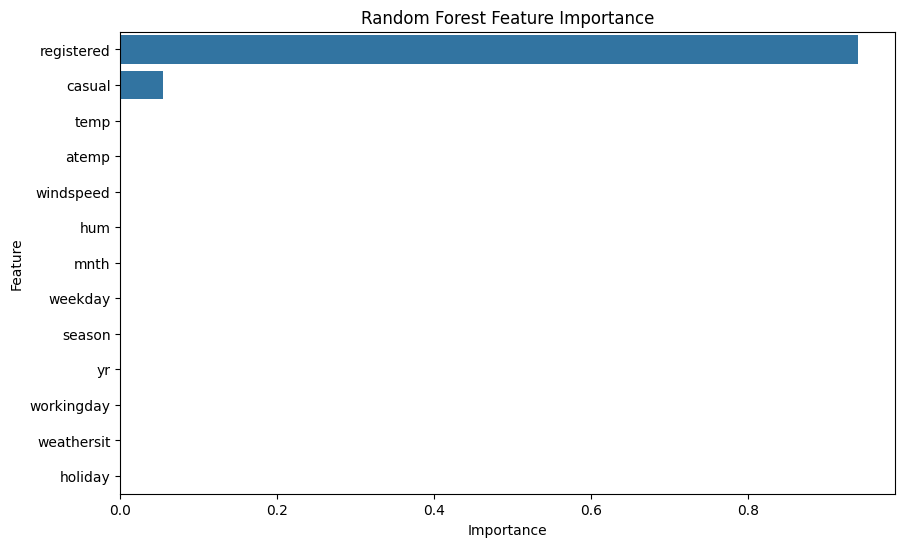

In [ ]:
# =========================================================
# Feature Importance Graph
# =========================================================
plt.figure(figsize=(10,6))
sns.barplot(data = importance, x = "Importance", y = "Feature")
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
results.append({
    "Model":"Random Forest",
    "MAE":mae_rf,
    "MSE":mse_rf,
    "RMSE":rmse_rf,
    "R2 Score":r2_rf
})
pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.249687e-12,2.301583e-24,1.517097e-12,1.000000
1,Decision Tree,1.255725e+02,2.860470e+04,1.691292e+02,0.990643
2,Random Forest,6.472939e+01,8.378663e+03,9.153504e+01,0.997259


#### 4. K-Nearest Neighbors

In [ ]:
# =========================================================
# Build K-Nearest Neighbors Regressor and Prediction
# =========================================================

knn = KNeighborsRegressor(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(y_pred_knn[:10])

[3952.6 2023.6 7288.6 3568.6 3321.4 2236.6 1595.8 1930.4 5049.2 2111.2]


In [ ]:
# =========================================================
# Evaluation Metrics
# =========================================================

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regressor Performance")
print("-"*40)
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE :", rmse_knn)
print("R2 Score :", r2_knn)

KNN Regressor Performance
----------------------------------------
MAE : 334.3007633587786
MSE : 190086.39847328243
RMSE : 435.9889889358244
R2 Score : 0.937822269674724


In [ ]:
comparison_knn = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_knn})
comparison_knn.head(10)

,Actual,Predicted
353,3750,3952.6
83,2210,2023.6
557,7446,7288.6
308,3926,3568.6
384,3163,3321.4
726,3095,2236.6
59,1851,1595.8
74,2192,1930.4
165,5180,5049.2
58,1446,2111.2


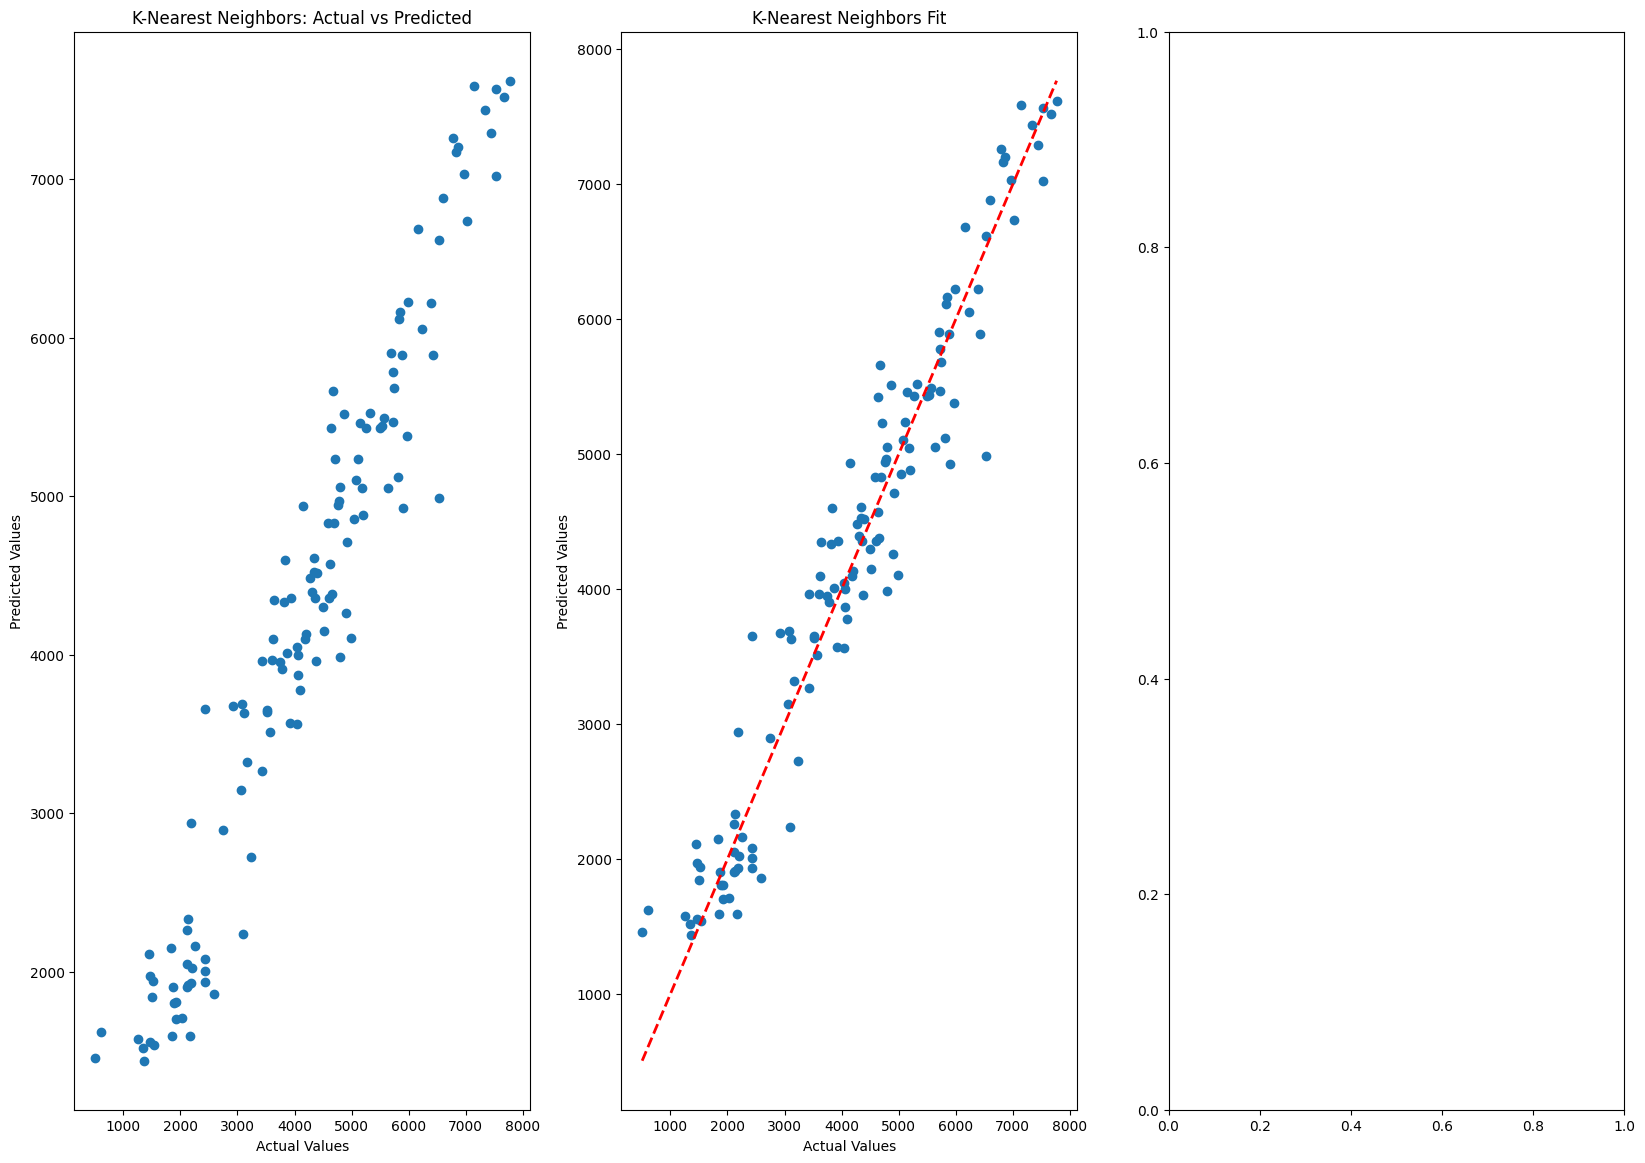

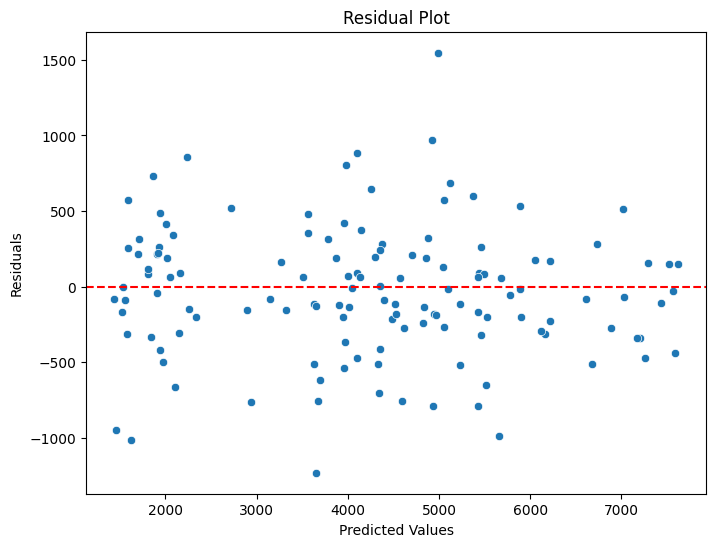

In [ ]:
# =========================================================
# Scatter Plot
# =========================================================

plt.figure(figsize=(20,14))
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("K-Nearest Neighbors: Actual vs Predicted")

# =========================================================
# Regression Line
# =========================================================
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_knn)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("K-Nearest Neighbors Fit")

plt.subplot(1,3,3)
residuals = y_test - y_pred_knn
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_pred_knn, y = residuals)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
results.append({
    "Model":"K-Nearest Neighbors",
    "MAE":mae_knn,
    "MSE":mse_knn,
    "RMSE":rmse_knn,
    "R2 Score":r2_knn
})
pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.249687e-12,2.301583e-24,1.517097e-12,1.000000
1,Decision Tree,1.255725e+02,2.860470e+04,1.691292e+02,0.990643
2,Random Forest,6.472939e+01,8.378663e+03,9.153504e+01,0.997259
3,K-Nearest Neighbors,3.343008e+02,1.900864e+05,4.359890e+02,0.937822


#### 5. Support Vector Machine

In [ ]:
# =========================================================
# Build Support Vector Regressor (SVR) and Prediction
# =========================================================

svr = SVR(kernel = 'rbf', C = 100, gamma = 'scale', epsilon = 0.1)
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
print(y_pred_svr[:10])

[3882.77788873 2153.14331785 7400.9223054  3851.72754577 3191.08118863
 3534.75498355 1626.02936213 2044.37605831 5094.9679679  2344.64749925]


In [ ]:
# =========================================================
# Evaluation Metrics
# =========================================================

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor Performance")
print("-"*40)
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE :", rmse_svr)
print("R2 Score :", r2_svr)

Support Vector Regressor Performance
----------------------------------------
MAE : 277.19836457383644
MSE : 189145.93267640818
RMSE : 434.9091085231582
R2 Score : 0.9381298983591952


In [ ]:
comparison_svr = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_svr
})
comparison_svr.head(10)

,Actual,Predicted
353,3750,3882.777889
83,2210,2153.143318
557,7446,7400.922305
308,3926,3851.727546
384,3163,3191.081189
726,3095,3534.754984
59,1851,1626.029362
74,2192,2044.376058
165,5180,5094.967968
58,1446,2344.647499


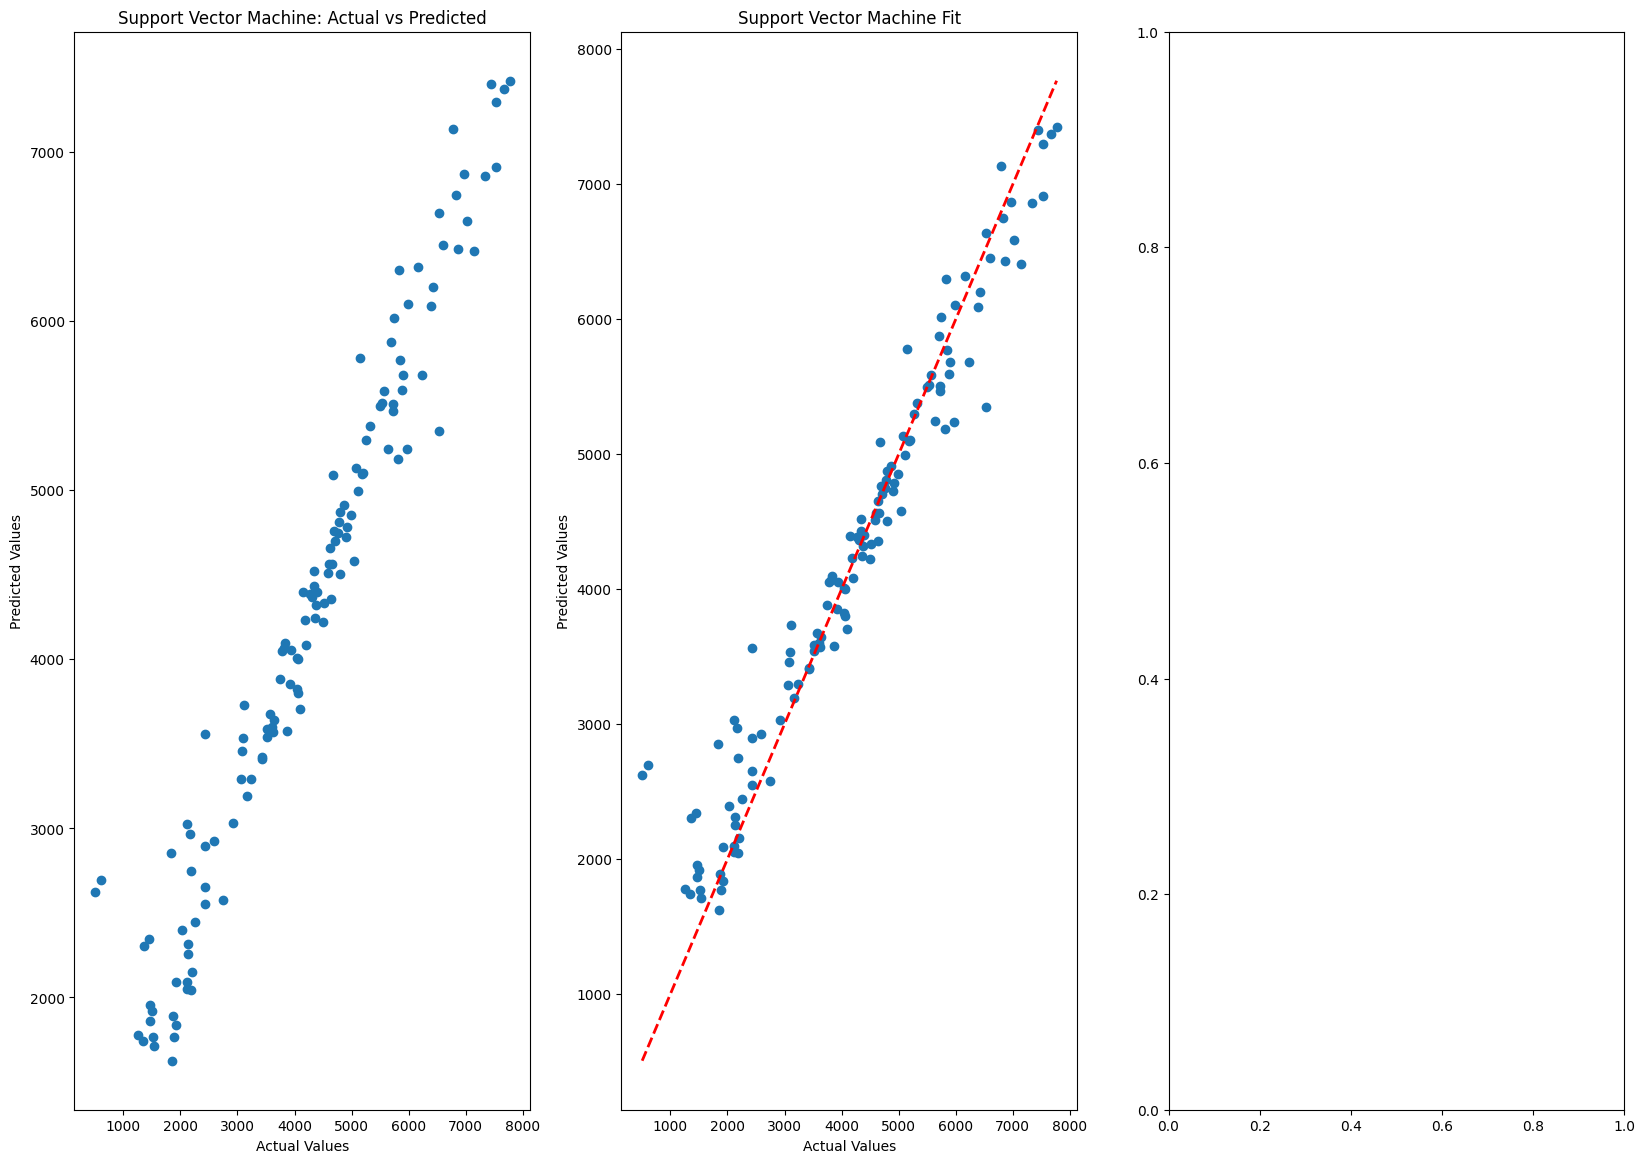

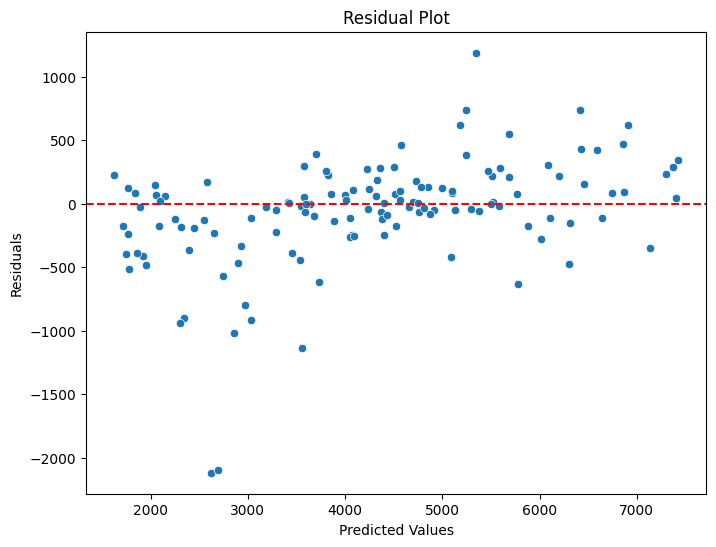

In [ ]:
# =========================================================
# Scatter Plot
# =========================================================

plt.figure(figsize=(20,14))
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Machine: Actual vs Predicted")

# =========================================================
# Regression Line
# =========================================================
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_svr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Machine Fit")

plt.subplot(1,3,3)
residuals = y_test - y_pred_svr
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_pred_svr, y = residuals)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
results.append({
    "Model":"Support Vector Regressor",
    "MAE":mae_svr,
    "MSE":mse_svr,
    "RMSE":rmse_svr,
    "R2 Score":r2_svr
})
pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.249687e-12,2.301583e-24,1.517097e-12,1.000000
1,Decision Tree,1.255725e+02,2.860470e+04,1.691292e+02,0.990643
2,Random Forest,6.472939e+01,8.378663e+03,9.153504e+01,0.997259
3,K-Nearest Neighbors,3.343008e+02,1.900864e+05,4.359890e+02,0.937822
4,Support Vector Regressor,2.771984e+02,1.891459e+05,4.349091e+02,0.938130


In [ ]:
# =========================================================
# Create Results DataFrame
# =========================================================

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.249687e-12,2.301583e-24,1.517097e-12,1.000000
1,Decision Tree,1.255725e+02,2.860470e+04,1.691292e+02,0.990643
2,Random Forest,6.472939e+01,8.378663e+03,9.153504e+01,0.997259
3,K-Nearest Neighbors,3.343008e+02,1.900864e+05,4.359890e+02,0.937822
4,Support Vector Regressor,2.771984e+02,1.891459e+05,4.349091e+02,0.938130


In [ ]:
results_df = results_df.sort_values(by = "R2 Score", ascending = False)
results_df.reset_index(drop = True, inplace = True)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.249687e-12,2.301583e-24,1.517097e-12,1.000000
1,Random Forest,6.472939e+01,8.378663e+03,9.153504e+01,0.997259
2,Decision Tree,1.255725e+02,2.860470e+04,1.691292e+02,0.990643
3,Support Vector Regressor,2.771984e+02,1.891459e+05,4.349091e+02,0.938130
4,K-Nearest Neighbors,3.343008e+02,1.900864e+05,4.359890e+02,0.937822


In [ ]:
best_model = results_df.iloc[0]
print("Best Model Details")
print("-"*50)
print(best_model)

Best Model Details
--------------------------------------------------
Model       Linear Regression
MAE                       0.0
MSE                       0.0
RMSE                      0.0
R2 Score                  1.0
Name: 0, dtype: object


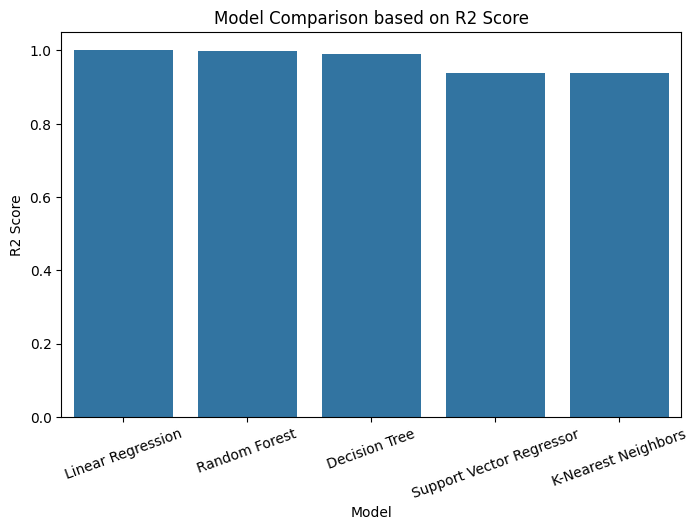

In [ ]:
# =========================================================
# R2 Score Comparison
# =========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)
plt.title("Model Comparison based on R2 Score")
plt.xticks(rotation=20)
plt.show()

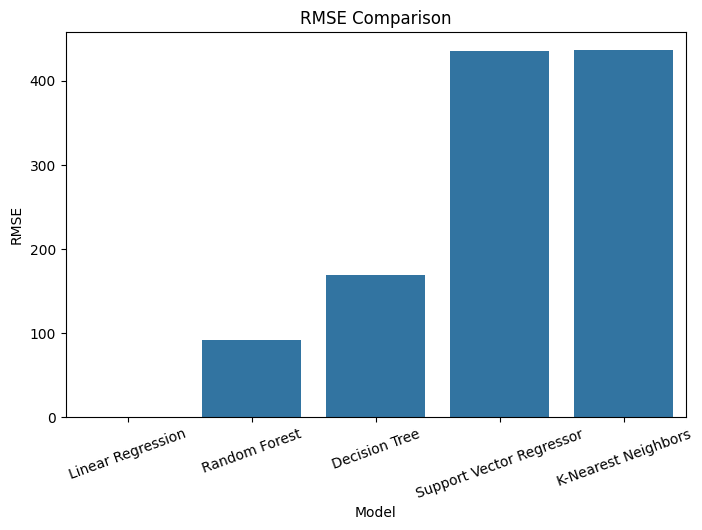

In [ ]:
# =========================================================
# RMSE Comparison
# =========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="RMSE",
    data=results_df
)
plt.title("RMSE Comparison")
plt.xticks(rotation=20)
plt.show()

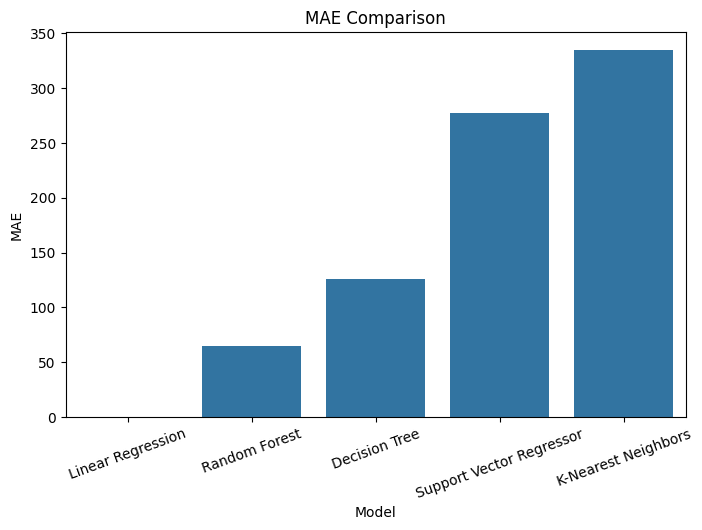

In [ ]:
# =========================================================
# MAE Comparison
# =========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="MAE",
    data=results_df
)
plt.title("MAE Comparison")
plt.xticks(rotation=20)
plt.show()

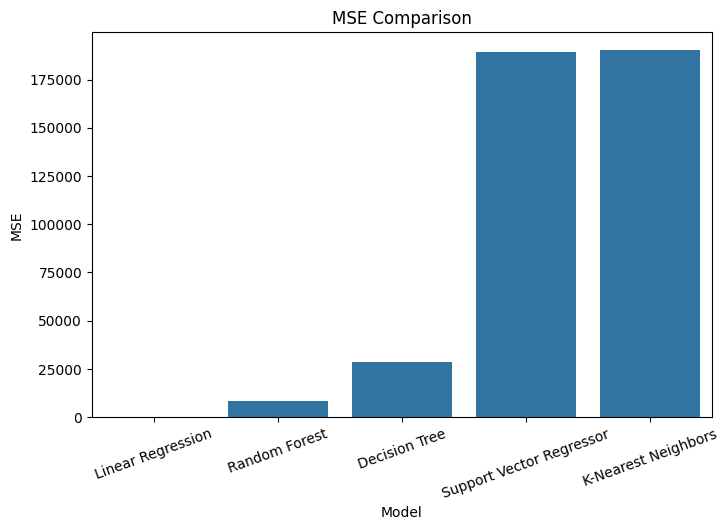

In [ ]:
# =========================================================
# MSE Comparison
# =========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="MSE",
    data=results_df
)
plt.title("MSE Comparison")
plt.xticks(rotation=20)
plt.show()

In [ ]:
# Summary
print(results_df)

                      Model           MAE           MSE          RMSE  \
0         Linear Regression  1.249687e-12  2.301583e-24  1.517097e-12   
1             Random Forest  6.472939e+01  8.378663e+03  9.153504e+01   
2             Decision Tree  1.255725e+02  2.860470e+04  1.691292e+02   
3  Support Vector Regressor  2.771984e+02  1.891459e+05  4.349091e+02   
4       K-Nearest Neighbors  3.343008e+02  1.900864e+05  4.359890e+02   

   R2 Score  
0  1.000000  
1  0.997259  
2  0.990643  
3  0.938130  
4  0.937822  


In [ ]:
# Saving Best Model

joblib.dump(random_forest, "Best_Bike_Sharing_Model.pkl")
print("Model Saved Successfully")

# Loading Saved Model

loaded_model = joblib.load("Best_Bike_Sharing_Model.pkl")
print("Model Loaded Successfully")

Model Saved Successfully
Model Loaded Successfully


In [ ]:
# Predict New Data

sample = X.iloc[[0]]
sample_scaled = scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)
print("Predicted Bike Rental Count :", prediction[0])

Predicted Bike Rental Count : 876.09


In [ ]:
# Compare Actual vs Predicted

print("Actual Value :", y.iloc[0])
print("Predicted Value :", prediction[0])

Actual Value : 985
Predicted Value : 876.09


In [ ]:
# Project Conclusion

print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print(f"""
1. The Bike Sharing dataset was successfully cleaned and preprocessed.

2. Exploratory Data Analysis (EDA) was performed to understand the
   relationship between the features and bike rental demand.

3. Five Regression Models were trained:
      • Linear Regression
      • Decision Tree Regressor
      • Random Forest Regressor
      • K-Nearest Neighbors Regressor
      • Support Vector Regressor

4. The models were evaluated using:
      • MAE
      • MSE
      • RMSE
      • R² Score

5. Based on the evaluation metrics, the best-performing model was selected.

6. The best model was saved using Joblib for future predictions.

7. This model can be used to estimate bike rental demand based on
   weather and seasonal conditions.
""")

PROJECT CONCLUSION

1. The Bike Sharing dataset was successfully cleaned and preprocessed.

2. Exploratory Data Analysis (EDA) was performed to understand the
   relationship between the features and bike rental demand.

3. Five Regression Models were trained:
      • Linear Regression
      • Decision Tree Regressor
      • Random Forest Regressor
      • K-Nearest Neighbors Regressor
      • Support Vector Regressor

4. The models were evaluated using:
      • MAE
      • MSE
      • RMSE
      • R² Score

5. Based on the evaluation metrics, the best-performing model was selected.

6. The best model was saved using Joblib for future predictions.

7. This model can be used to estimate bike rental demand based on
   weather and seasonal conditions.

